## BMI CALCULATOR
### input height,weight -> calculate BMI -> label_BMI -> output
#### state : weigth,height,bmi

#### start -> calculate BMI -> END

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float

In [3]:
def bmi_calculator(state: BMIState) -> BMIState:

    weight = state["weight"]
    height = state["height"]
    bmi = weight / (height ** 2)

    state["bmi"] = bmi
    
    return state

In [4]:
# define the graph
graph = StateGraph(BMIState)

# define the nodes
graph.add_node("bmi_calculator",bmi_calculator)

# define the edges
graph.add_edge(START, "bmi_calculator")
graph.add_edge("bmi_calculator", END)

# graph compile
workflow = graph.compile()

In [5]:
# execute the workflow
initial_state = {"weight": 80, "height": 1.78}

final_state = workflow.invoke(initial_state)

In [6]:
print(final_state)

{'weight': 80, 'height': 1.78, 'bmi': 25.24933720489837}


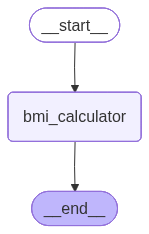

In [7]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [8]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [9]:
# define state graph

class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [10]:
def label_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']
    
    if bmi < 18.5:
        category = 'Underweight'
    elif 18.5 <= bmi < 25:
        category = 'Normal weight'
    elif 25 <= bmi < 30:
        category = 'Overweight'
    else:
        category = 'Obesity'
    
    state['category'] = category
    return state

In [11]:
def calculate_bmi(state: BMIState) -> BMIState:

    weight_kg = state['weight_kg']
    height_m = state['height_m']
    
    bmi = weight_kg / (height_m ** 2)
    state['bmi'] = round(bmi, 2)
    
    return state

In [12]:
# define a simple state graph
graph = StateGraph(BMIState)

# add a node to the graph
graph.add_node("calculate_bmi",calculate_bmi)
graph.add_node('label_bmi',label_bmi)


# add edges to the graph
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "label_bmi")
graph.add_edge("label_bmi", END)

# compile the graph
workflow = graph.compile()


In [13]:
initial_state = {"weight_kg": 80, "height_m": 1.78}

# execute the graph
final_state = workflow.invoke(initial_state)

In [14]:
final_state

{'weight_kg': 80, 'height_m': 1.78, 'bmi': 25.25, 'category': 'Overweight'}

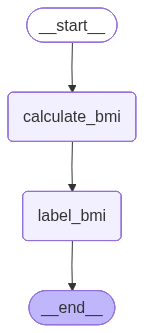

In [15]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())